In [1]:
import numpy as np
import lmt_sim.lmt_simulation as sim

n_lmt = 4
atom_radius = 0.0
beam_waist = 5e-3
initial_velocity_z = 0.0
detuning_hz = sim.RECOIL_FREQUENCY_HZ


In [2]:

m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
    position_x=atom_radius,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=initial_velocity_z,
    c0=1.0,
    c1=0.0,
)

omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + detuning_hz)
squiggly_amplitudes = sim.transform_state_vector(
    m,
    amplitudes,
    internal_is_ground,
    omega_laser=omega_laser,
    t=0.0,
    z=0.0,
    vz=initial_velocity_z,
    inverse=False,
)

for i in range(n_lmt):
    laser_direction = +1 if i % 2 == 0 else -1
    m, squiggly_amplitudes, internal_is_ground, positions, velocities = sim.do_gaussian_pulse(
        m,
        squiggly_amplitudes,
        internal_is_ground,
        positions,
        velocities,
        pulse_detuning=detuning_hz,
        t_pulse=sim.T_PI,
        on_axis_rabi_freq=sim.RABI_FREQ,
        beam_waist=beam_waist,
        pulse_phase=0.0,
        k_sign=laser_direction,
        vz=initial_velocity_z,
    )

ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
    m, squiggly_amplitudes, internal_is_ground
)
excited_fraction = excited_prob / (ground_prob + excited_prob)
ground_prob, excited_prob, excited_fraction

(np.float64(0.0026544883511430434),
 np.float64(0.997345511648857),
 np.float64(0.997345511648857))

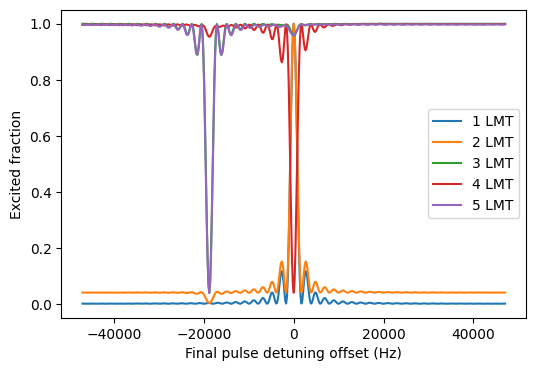

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

n_lmts = [1, 2, 3, 4, 5]
atom_radius = 0.0
beam_waist = 5e-3
initial_velocity_z = 0.0
base_detuning_hz = sim.RECOIL_FREQUENCY_HZ

final_detuning_offsets_hz = np.linspace(-10.0, 10.0, 501) * sim.RECOIL_FREQUENCY_HZ

plt.figure(figsize=(6, 4))
for n_lmt in n_lmts:

    sequence = []
    for i in range(n_lmt - 1):
        sequence.append(
            seq.Pulse(
                k=+1 if i % 2 == 0 else -1,
                detuning_hz=i * sim.RECOIL_FREQUENCY_HZ,
                phi=0.0,
                label=f"N={i}",
                rabi_frequency=sim.RABI_FREQ,
                duration=sim.T_PI,
            )
        )

    m, positions, velocities, amplitudes, internal_is_ground = sim.make_atom_states(
        position_x=atom_radius,
        position_y=0.0,
        position_z=0.0,
        initial_velocity_z=initial_velocity_z,
        c0=1.0,
        c1=0.0,
    )

    if sequence:
        result = seq.run_pulse_sequence_in_lab_frame(
            m,
            positions,
            velocities,
            amplitudes,
            internal_is_ground,
            pulse_sequence=sequence,
        )
        if result is None:
            raise RuntimeError("Atom was cleared out")
        m, positions, velocities, amplitudes, internal_is_ground, _, _ = result

    m_saved = m.copy()
    positions_saved = positions.copy()
    velocities_saved = velocities.copy()
    amplitudes_saved = amplitudes.copy()
    internal_is_ground_saved = internal_is_ground.copy()

    final_laser_direction = +1 if (n_lmt - 1) % 2 == 0 else -1

    excited_scan = []
    for detuning_offset_hz in final_detuning_offsets_hz:
        final_detuning_hz = base_detuning_hz + detuning_offset_hz

        m_trial = m_saved.copy()
        positions_trial = positions_saved.copy()
        velocities_trial = velocities_saved.copy()
        amplitudes_trial = amplitudes_saved.copy()
        internal_is_ground_trial = internal_is_ground_saved.copy()

        final_pulse = seq.Pulse(
            k=final_laser_direction,
            detuning_hz=final_detuning_hz,
            phi=0.0,
            label=f"Final pulse",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )

        result_final = seq.run_pulse_sequence_in_lab_frame(
            m_trial,
            positions_trial,
            velocities_trial,
            amplitudes_trial,
            internal_is_ground_trial,
            pulse_sequence=[final_pulse],
        )

        if result_final is None:
            raise RuntimeError("Atom was cleared out by final pulse")

        (
            m_trial,
            positions_trial,
            velocities_trial,
            amplitudes_trial,
            internal_is_ground_trial,
            _,
            _,
        ) = result_final

        ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(
            m_trial, amplitudes_trial, internal_is_ground_trial
        )
        excited_scan.append(excited_prob / (ground_prob + excited_prob))

    plt.plot(
        final_detuning_offsets_hz,
        excited_scan,
        label=f"{n_lmt} LMT",
    )


plt.xlabel("Final pulse detuning offset (Hz)")
plt.ylabel("Excited fraction")
plt.legend()

# plt.xlim([-1000, 1000])

In [5]:
sim.RECOIL_FREQUENCY_HZ

4707.028607971276